# 4.5.1 候选函数与局部稳定性证明

## 学习目标与先修知识

能从正定性（positive definiteness）和沿轨迹（trajectory）导数（derivative）构造稳定性论证，解释子水平集（sublevel set）与局部区域，区分稳定、渐近稳定（asymptotic stability）和全局结论。

先修：第 3 篇的梯度（gradient）与链式法则（chain rule）；本篇的吸引域（basin of attraction）和局部分析。 [复习上一节](../04-混沌与可预测范围/03-有限时间增长率与算术精度.ipynb)。

## 具体问题

不逐条模拟所有可能初值（initial condition），能否论证一个平衡（equilibrium）会抵抗扰动并逐渐恢复？寻找一个像能量一样沿运动不增加的量，但先明确“能量一样”需要满足什么。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
points=np.array([-1.2,-.5,0,.5,1.2])
display(Markdown(show_table(['x','V=x²/2','系统 x′=−x 的 V′','系统 x′=−x+x³ 的 V′'],zip(points,points**2/2,-points**2,-points**2+points**4))))

| x | V=x²/2 | 系统 x′=−x 的 V′ | 系统 x′=−x+x³ 的 V′ |
| --- | --- | --- | --- |
| -1.2 | 0.72 | -1.44 | 0.6336 |
| -0.5 | 0.125 | -0.25 | -0.1875 |
| 0 | 0 | -0 | 0 |
| 0.5 | 0.125 | -0.25 | -0.1875 |
| 1.2 | 0.72 | -1.44 | 0.6336 |

## 模型假设

状态（state）为相对平衡的无量纲（dimensionless）偏差，时间已尺度归一。先研究 x′=−x，再研究 x′=−x+x³；V=x²/2 是数学候选量，没有声称它就是生理系统的物理能量。

方程光滑，原点为平衡。局部例在 |x|<1 内具有吸引作用；图中同时展示区域内外的轨迹，以比较变化方向。

## 数学解释与推导

原点**稳定**表示：任意给定小邻域，总能找到更小初始邻域，使从其中出发的解一直留在指定邻域。**渐近稳定**还要求足够邻近的解最终趋向原点。稳定不自动意味着恢复到零；下一节纯旋转会给出反例。

**Lyapunov 候选函数**是人为构造、用来检查稳定性的量，可以先把它理解成“能量式指标”。本例 $V=x^2/2$ 随偏差大小增加；它不一定以焦耳计量，也不必是真实物理能量。即使 V 沿运动下降，能否推出收敛仍需检查下降范围和以下条件。相对原点的正定（positive definite）候选函数要求 V(0)=0，区域内每个非零点 V>0。沿解的变化由链式法则给出
$$\dot V=\nabla V\cdot f(x).$$
在足够光滑、原点为平衡等条件下，若一个邻域内 V 正定且 V′≤0，可用它证明稳定；若非零点 V′<0，可得到局部渐近稳定（local asymptotic stability）。这里陈述判据和关键几何理由，完整定理证明列为拓展。

关键是**子水平集** Ω_c={x:V(x)≤c}：在边界 V=c 上 V′≤0，轨迹不能沿增加 V 的方向穿出。在有限维空间里，紧集（compact set）指闭且有界的集合：包含边界，又不会延伸到无限远。正向不变（positively invariant）表示从集合内出发，之后一直留在其中。选取紧的 Ω_c，并使它完全包含在判据适用区域内，便把“全区域符号”与“轨迹一直留在区域里”连接起来。仅说某条轨迹上 V 下降并没有完成这个步骤。

对 x′=−x，V′=x(−x)=−x²。V 在全空间正定，随 |x|→∞ 趋于∞（径向无界（radially unbounded）），子水平集紧，解全局存在，因此可得全局渐近稳定；闭式 x=x0 exp(−τ) 也直接核对。

对 x′=−x+x³，V′=−x²+x⁴=−x²(1−x²)。仅 0<|x|<1 严格负，±1 为别的平衡，外侧反而正。选任意 0<c<1/2，有 Ω_c⊂(−1,1)，所以得到局部论证。每个 |x0|<1 都能选这样的 c 包含它，结合相线（phase line）可知吸引域为 (−1,1)。不能因为 V 在全空间正定就忽略 V′ 的区域限制。

Lyapunov 函数（Lyapunov function）是状态上的标量候选和符号判据；上一节的 Lyapunov 指数（Lyapunov exponent）描述切向扰动的增长率。二者同姓，数学对象与证据条件不同。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def local_energy(points):
    values=[x*x/2 for x in points]
    derivatives=[-x*x+x**4 for x in points]
    strict=[0<abs(x)<1 for x in points]
    return values,derivatives,strict

## 对照实验

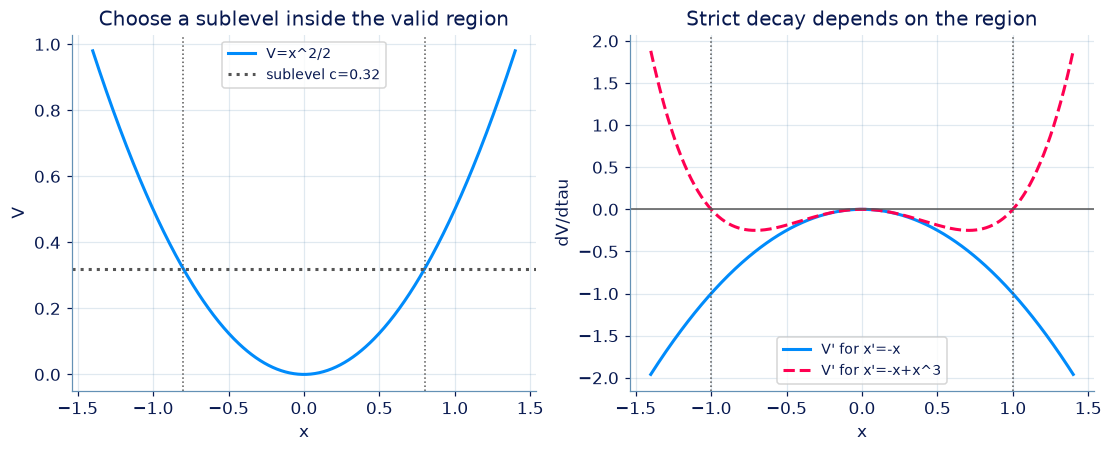

In [4]:
grid=np.linspace(-1.4,1.4,501)
values,derivatives,_=local_energy(grid)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(grid,values,color=BLUE,label='V=x^2/2')
axes[0].axhline(.32,color=GRAY,ls=':',label='sublevel c=0.32')
axes[0].axvline(-.8,color=GRAY,ls=':',lw=1);axes[0].axvline(.8,color=GRAY,ls=':',lw=1)
axes[1].plot(grid,-grid**2,color=BLUE,label="V' for x'=-x")
axes[1].plot(grid,derivatives,color=PINK,ls='--',label="V' for x'=-x+x^3")
axes[1].axhline(0,color=GRAY,lw=1)
for edge in [-1,1]:axes[1].axvline(edge,color=GRAY,ls=':',lw=1)
axes[0].set(xlabel='x',ylabel='V',title='Choose a sublevel inside the valid region')
axes[1].set(xlabel='x',ylabel='dV/dtau',title='Strict decay depends on the region')
for ax in axes:ax.legend(fontsize=9)
plt.show()

## 结果解释

左图 c=0.32 对应 |x|≤0.8，完整落在局部例的严格衰减区域内部；右图在 ±1 之外显式显示失效。图帮助理解符号，但真正的区域结论来自因式分解，不由像素或网格点数证明。

把 c 改成 0.6 后，子水平集越过 ±1，原证明不再适用。应修改结论范围，而不是删除不符合预期的初值。

### 独立核对

数值差分只辅助核对链式法则实现；证明区域内处处成立的依据是 −x²(1−x²) 的解析符号。

In [5]:
V,dV,strict=local_energy([-1,-.5,0,.5,1,2])
assert V==[.5,.125,0,.125,.5,2]
assert dV==[0,-.1875,0,-.1875,0,12]
assert strict==[False,True,False,True,False,False]
for x in [-.8,-.3,.3,.8]:
    eps=1e-6
    directional=(((x+eps*(-x+x**3))**2/2)-((x-eps*(-x+x**3))**2/2))/(2*eps)
    assert abs(directional-(-x*x+x**4))<1e-9
print('手算边界与沿向量场方向导数一致；区域结论仍依赖解析因式分解。')

手算边界与沿向量场方向导数一致；区域结论仍依赖解析因式分解。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：逐点计算候选函数与导数

系统 x′=−x+x³，候选函数 V=x²/2。返回各点的 V、沿轨迹（trajectory）导数（derivative），以及是否位于严格衰减区域。

**函数与代码模板**

```python
def solve(
    points: list[float],
) -> tuple[list[float], list[float], list[bool]]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `points` | `list[float]` | 需要计算的状态（state）点。 | 1 |

**返回值**

按以下顺序返回元组：(values, derivatives, strict)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 各点 V。 | 1 |
| `derivatives` | `list[float]` | 各点 dV/dt。 | 1 |
| `strict` | `list[bool]` | 是否满足 0<abs(x)<1。 | 1 |

**计算规则**

V=x²/2；dV/dt=x*(−x+x³)=−x²+x⁴。strict 在 0 和 ±1 都为 False；点上成立不等于已经证明整个区域。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- 1≤len(points)≤50；每项在 [−2,2]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| points | 需要计算的状态（state）点。 | [-1, -0.5, 0, 0.5, 1, 2] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
points = [-1, -0.5, 0, 0.5, 1, 2]

result = solve(points)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| values | 各点 V。 | [0.5, 0.125, 0.0, 0.125, 0.5, 2.0] | 1 |
| derivatives | 各点 dV/dt。 | [0, -0.1875, 0, -0.1875, 0, 12] | 1 |
| strict | 是否满足 0<abs(x)<1。 | [False, True, False, True, False, False] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.5, 0.125, 0.0, 0.125, 0.5, 2.0],
                   [0, -0.1875, 0, -0.1875, 0, 12],
                   [False, True, False, True, False, False])
```

**样例解释**

x=±0.5 时 V=0.125、导数为 −0.1875；x=0、±1 导数为零；x=2 导数为 12，不在局部衰减区。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：逐点计算候选函数与导数](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-local-energy)

### 第 2 题 · 多项选择题：正定要求检查哪几项

要用 V 研究原点，哪些是正定性（positive definiteness）的要求？

- **A.** V 可以在另一非零状态（state）等于零而仍称相对原点正定（positive definite）。
- **B.** V(0)=0。
- **C.** 区域内所有非零 x 都有 V(x)>0。
- **D.** 只检查采样点 V≥0 即可证明。

[作答：正定要求检查哪几项](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-positive-definite)

### 第 3 题 · 多项选择题：为什么只在一个区域内作结论

对于 x′=−x+x³、V=x²/2，哪些成立？

- **A.** 原点局部渐近稳定（local asymptotic stability）。
- **B.** 对任意 |x0|<1，可选包含初值（initial condition）的子水平集（sublevel set） V≤c<1/2，使轨迹（trajectory）保持在衰减区。
- **C.** 因为 V 正定（positive definite），所以所有实数初值都趋向 0。
- **D.** ±1 是边界平衡（equilibrium），不能并入原点的吸引域（basin of attraction）。

[作答：为什么只在一个区域内作结论](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-local-domain)

### 第 4 题 · 单项选择题：全局结论还需要什么

对 x′=−x，V=x²/2，V′=−x²。哪组理由支持全局渐近稳定（asymptotic stability）？

- **A.** 正定（positive definite）、全空间非零点严格负导数（derivative）、径向无界（radially unbounded）且解全局存在；也可直接用 x=x0 exp(−t) 核对。
- **B.** 仅因为 V 有平方。
- **C.** 只在原点导数为零就足够。
- **D.** 仅因为画出的五条轨迹（trajectory）下降。

[作答：全局结论还需要什么](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-global-decay)

### 第 5 题 · 单项选择题：同姓不代表同一种判据

Lyapunov 函数（Lyapunov function）与 Lyapunov 指数（Lyapunov exponent）有何区别？

- **A.** 函数为正意味着指数为正。
- **B.** 指数的有限时间估计可自动替代函数的区域证明。
- **C.** 前者是状态（state）上的候选标量及符号判据，后者描述邻近扰动沿轨迹（trajectory）的增长率。
- **D.** 它们都是同一条曲线的不同名字。

[作答：同姓不代表同一种判据](http://127.0.0.1:8000/chapters/04-05-%E7%94%A8%20Lyapunov%20%E5%87%BD%E6%95%B0%E5%88%86%E6%9E%90%E7%A8%B3%E5%AE%9A%E6%80%A7/practice/?question=p04-function-vs-exponent)